# Raman analysis of rock materials — Python edition

**Gypsum CaSO₄·2H₂O vs. marble (calcite, CaCO₃)**, five spectra each, ten in total.

This notebook does exactly the same thing as `r/rock_raman_tutorial.R` in the same
repository, and as the **PLS-DA widget** of `orange-spectra` in Orange. All three agree to
better than six decimal places — the last section verifies it.

You need `numpy`, `scipy`, `pandas` and `matplotlib`. `scikit-learn` and `orange-spectra`
are optional, for comparison only.

```bash
pip install numpy scipy pandas matplotlib scikit-learn orange-spectra
```

In [1]:
import math
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse.linalg import spsolve

np.random.seed(20260814)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": False,
                     "axes.unicode_minus": False})

COL = {"gypsum": "#0F766E", "marble": "#4338CA"}
MRK = {"gypsum": "^",       "marble": "s"}
XLAB = r"Raman shift (cm$^{-1}$)"

## 1. Read the data

The layout is **one row per spectrum, one column per wavenumber**. Column 1 is `ID`,
column 2 is `type` (the class), and from column 3 onwards **the column name is the wavenumber**.

In [2]:
d = pd.read_csv("../data/rock_raman_2class_raw.csv")
wn  = np.array([float(c) for c in d.columns[2:]])
X   = d.iloc[:, 2:].to_numpy(float)
lab = d["type"].to_numpy()
ids = d["ID"].to_numpy()

print("X:", X.shape, " wavenumbers:", f"{wn.min():.1f} - {wn.max():.1f} cm-1")
print("classes:", {c: int((lab == c).sum()) for c in sorted(set(lab))})
d.iloc[:, :6].head()

X: (10, 664)  wavenumbers: 150.0 - 1798.5 cm-1
classes: {'gypsum': 5, 'marble': 5}


,ID,type,150.004,153.010,156.013,159.014
0,gypsum1,gypsum,132,149,118,96
1,gypsum2,gypsum,148,160,116,91
2,gypsum3,gypsum,139,151,116,102
3,gypsum4,gypsum,140,151,122,108
4,gypsum5,gypsum,148,155,118,105


> **Variables outnumber samples 66 to one** (664 wavenumbers, 10 samples). This is the
> p ≫ n regime, and it means any flexible model can separate the data perfectly — even
> with randomly shuffled labels. Section 7 handles that with an exact permutation test.

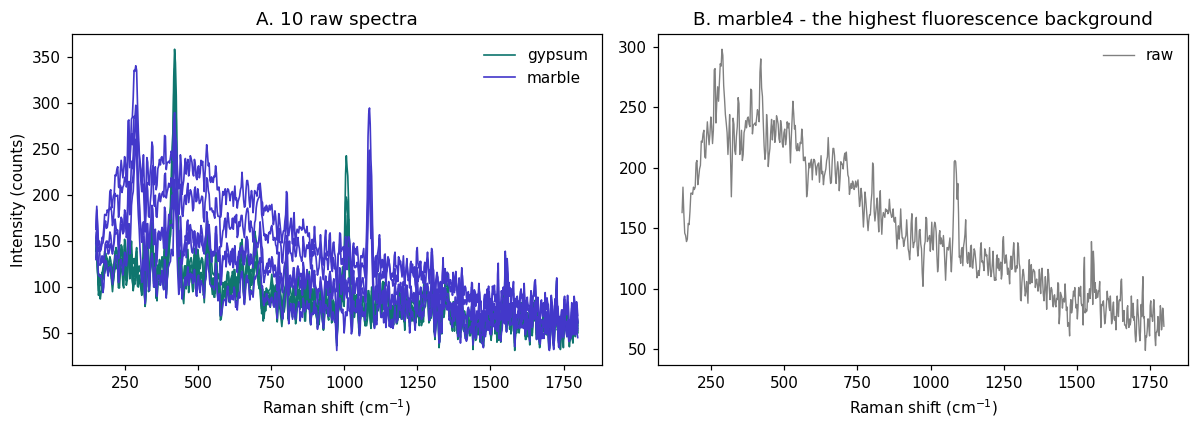

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for i, l in enumerate(lab):
    ax[0].plot(wn, X[i], lw=1.1, color=COL[l], label=l if l not in
               [lab[j] for j in range(i)] else None)
ax[0].set(xlabel=XLAB, ylabel="Intensity (counts)", title="A. 10 raw spectra")
ax[0].legend(frameon=False)
k = list(ids).index("marble4")
ax[1].plot(wn, X[k], color="grey", lw=.9, label="raw")
ax[1].set(xlabel=XLAB, title="B. marble4 - the highest fluorescence background")
ax[1].legend(frameon=False)
fig.tight_layout()

## 2. Preprocessing: ALS baseline, Savitzky–Golay, SNV

Three functions, under ten lines each. They **must correspond line by line to the R
version**, or the numbers will not match later.

### 2-1 ALS (asymmetric least squares) baseline
Find a curve that is as smooth as possible while hugging the data from below.
`lam` controls smoothness; `p = 0.01` gives points above the baseline (the peaks) only 1% weight.

In [4]:
def als(y, lam=1e4, p=0.01, niter=15):
    m = len(y)
    D = sparse.diags([1., -2., 1.], [0, 1, 2], shape=(m - 2, m), format="csc")
    DD = lam * (D.T @ D)
    w = np.ones(m)
    for _ in range(niter):
        W = sparse.diags(w, 0, format="csc")
        z = spsolve((W + DD).tocsc(), w * y)
        w = p * (y > z) + (1 - p) * (y <= z)
    return z

### 2-2 Savitzky–Golay
Fit a low-order polynomial in a sliding window and replace each point with the polynomial's
value at the centre. Better than a moving average because **it does not flatten peaks**.

This is written out by hand rather than using `scipy.signal.savgol_filter` on purpose: scipy
defaults to `mode='interp'` at the edges, while the R version pads with the end values. The
difference affects only the outermost points, but making the two agree *exactly* requires
writing them the same way.

In [5]:
def sg(y, w=9, poly=3, deriv=0):
    hw = (w - 1) // 2
    k  = np.arange(-hw, hw + 1)
    A  = np.vander(k, poly + 1, increasing=True)
    C  = np.linalg.solve(A.T @ A, A.T)
    cf = C[deriv] * math.factorial(deriv)
    yp = np.r_[np.repeat(y[0], hw), y, np.repeat(y[-1], hw)]
    return np.array([cf @ yp[i:i + w] for i in range(len(y))])

def snv(y):
    return (y - y.mean()) / y.std(ddof=1)      # ddof=1 to match R's sd()

> `snv` uses `ddof=1`. numpy's `std()` defaults to the population standard deviation
> (ddof=0); R's `sd()` is the sample standard deviation. Mismatched defaults like this are
> the most common cross-language reproducibility trap.

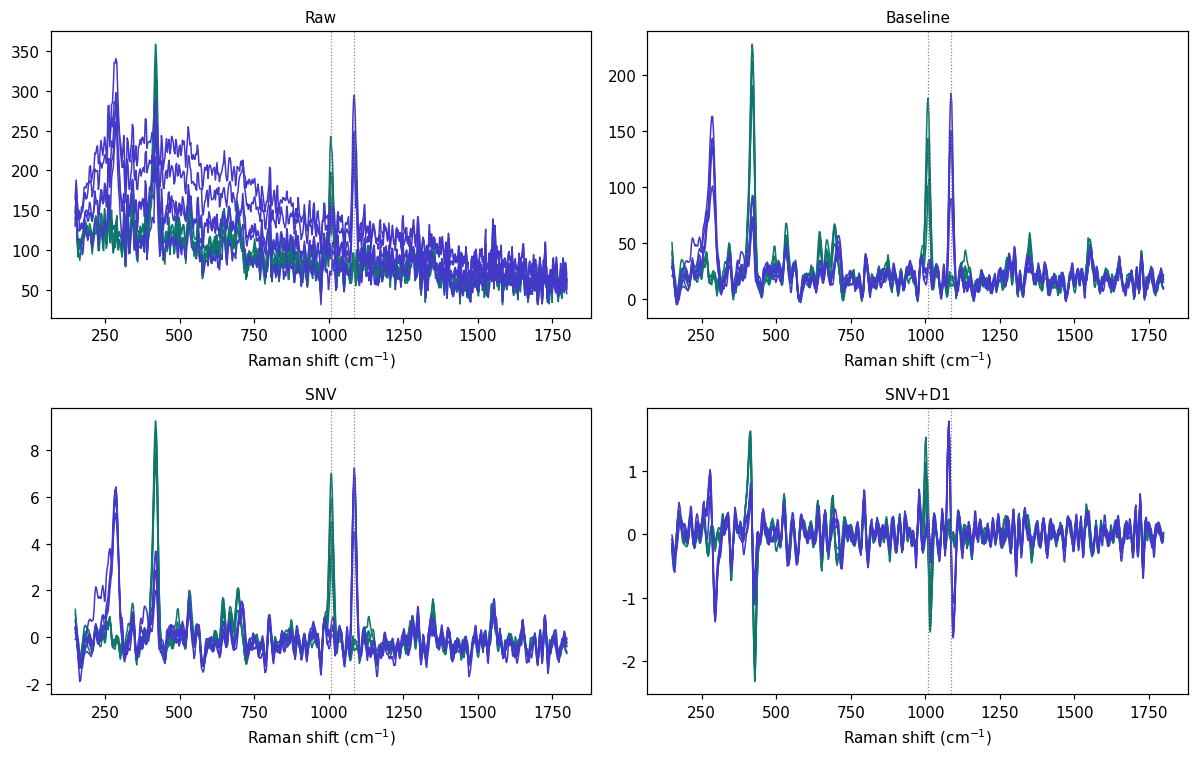

In [6]:
BASE = np.array([als(y) for y in X])           # the fluorescence baseline
Xbl  = np.array([sg(y) for y in X - BASE])     # baseline-corrected + smoothed <- main
Xsnv = np.array([snv(y) for y in Xbl])
Xd1  = np.array([sg(y, deriv=1) for y in Xsnv])
SETS = {"Raw": X, "Baseline": Xbl, "SNV": Xsnv, "SNV+D1": Xd1}

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for axi, (nm, M) in zip(axes.ravel(), SETS.items()):
    for i, l in enumerate(lab):
        axi.plot(wn, M[i], lw=1.0, color=COL[l])
    axi.set_title(nm, fontsize=10); axi.set_xlabel(XLAB)
    for v in (1008, 1086): axi.axvline(v, color="grey", ls=":", lw=.8)
fig.tight_layout()

### 2-3 Check: does the Python preprocessing match R?

`data/rock_preprocessed.csv` in this repository was **produced by the R script**. Compare it
with what Python has just computed.

In [7]:
ref = pd.read_csv("../data/rock_preprocessed.csv")
Xr  = ref.iloc[:, 2:].to_numpy(float)
diff = np.abs(Xbl - Xr).max()
print(f"max absolute difference between R and Python = {diff:.3e}")
print("(R rounds to six decimals on export, so a residual of order 1e-6 is expected)")
assert diff < 1e-5

max absolute difference between R and Python = 5.026e-07
(R rounds to six decimals on export, so a residual of order 1e-6 is expected)


## 3. Band assignment: chemistry before statistics

| Mineral | cm⁻¹ | Assignment |
|---|---|---|
| gypsum CaSO₄·2H₂O | 413 / 493 | SO₄ symmetric bend ν₂ |
| | 620 / 670 | SO₄ antisymmetric bend ν₄ |
| | **1008** | **SO₄ symmetric stretch ν₁ — strongest, diagnostic** |
| | 1135 | SO₄ antisymmetric stretch ν₃ |
| calcite CaCO₃ | 156 / 282 | lattice modes (translation / libration) |
| | 712 | CO₃ in-plane bend ν₄ |
| | **1086** | **CO₃ symmetric stretch ν₁ — strongest, diagnostic** |
| | 1435 | CO₃ antisymmetric stretch ν₃ (very weak in Raman) |

In [8]:
def peakh(M, t, tol=8):
    j = (wn >= t - tol) & (wn <= t + tol)
    return M[:, j].max(axis=1)

def snr(M, t):
    bg = M[:, ((wn > 930) & (wn < 985)) | ((wn > 1150) & (wn < 1250))]
    return (peakh(M, t) - bg.mean(axis=1)) / bg.std(axis=1, ddof=1)

qc = pd.DataFrame({"sample": ids, "type": lab,
                   "S/N @1008": snr(Xbl, 1008).round(1),
                   "S/N @1086": snr(Xbl, 1086).round(1),
                   "h(419)":    peakh(Xbl, 419, 4).round(1),
                   "fluorescence": BASE.mean(axis=1).round(1)})
qc

,sample,type,S/N @1008,S/N @1086,h(419),fluorescence
0,gypsum1,gypsum,18.1,0.9,183.6,61.2
1,gypsum2,gypsum,25.3,0.5,187.5,61.2
2,gypsum3,gypsum,17.7,0.7,212.5,67.2
3,gypsum4,gypsum,11.9,0.8,190.9,65.4
4,gypsum5,gypsum,10.8,1.1,227.8,72.8
5,marble1,marble,1.5,16.9,88.9,85.7
6,marble2,marble,1.9,15.0,92.5,60.4
7,marble3,marble,1.0,16.4,73.2,84.1
8,marble4,marble,2.7,9.6,64.6,124.5
9,marble5,marble,2.3,23.9,68.0,111.6


Thresholds: **S/N ≥ 3 counts as detected, ≥ 10 as reliable**. Gypsum's 1008 and marble's
1086 are both far above threshold — two clean, usable groups.

Now look at the **`h(419)` column**: 419 cm⁻¹ appears in **both** groups, and calcite has no
vibrational mode there at all. A band that appears in a sample which chemically should not
have it is not sample signal — it is an **instrument artefact**. Remember it; in section 6
the model will rank it second by VIP.

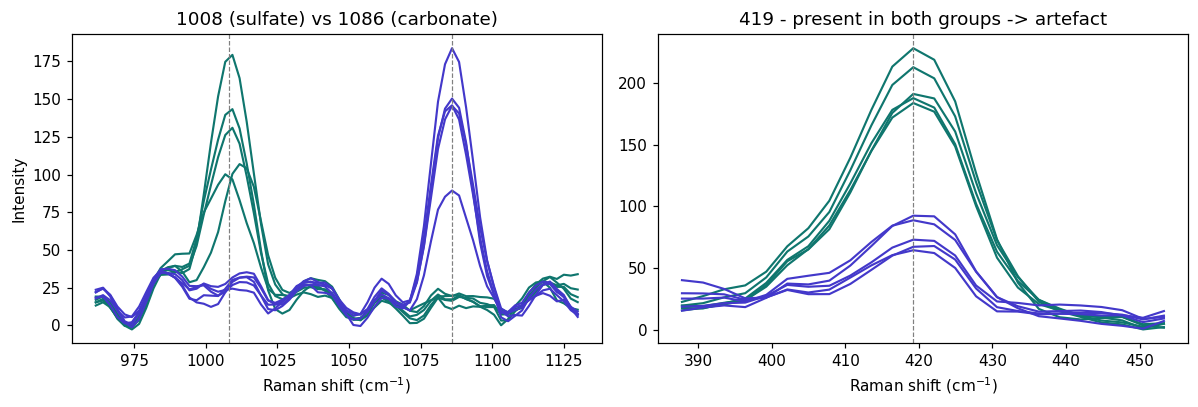

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for i, l in enumerate(lab):
    m = (wn > 960) & (wn < 1130); ax[0].plot(wn[m], Xbl[i][m], color=COL[l], lw=1.4)
    m2 = (wn > 385) & (wn < 455);  ax[1].plot(wn[m2], Xbl[i][m2], color=COL[l], lw=1.4)
ax[0].set(xlabel=XLAB, ylabel="Intensity", title="1008 (sulfate) vs 1086 (carbonate)")
for v in (1008, 1086): ax[0].axvline(v, color="grey", ls="--", lw=.8)
ax[1].set(xlabel=XLAB, title="419 - present in both groups -> artefact")
ax[1].axvline(419.2, color="grey", ls="--", lw=.8)
fig.tight_layout()

## 4. PCA — unsupervised

`center=True` is mandatory. **Do not scale the individual wavenumber columns** for spectra:
standardising promotes a pure-noise wavenumber to the same importance as the 1086 band, and
PC1 ends up describing noise. (This is the opposite of the usual advice for tabular data.)

The SVD is written out here so every step is visible; `sklearn.decomposition.PCA` gives the
same result.

In [10]:
def pca(M):
    Xc = M - M.mean(axis=0)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    ve = 100 * S**2 / (S**2).sum()
    return U * S, Vt, ve            # scores, loadings (one PC per row), % variance

for nm, M in SETS.items():
    _, _, ve = pca(M)
    print(f"  {nm:<9s} PC1 {ve[0]:5.1f}%   PC2 {ve[1]:5.1f}%   PC3 {ve[2]:5.1f}%")

scores, load, ve = pca(Xbl)

  Raw       PC1  85.8%   PC2  10.7%   PC3   1.0%
  Baseline  PC1  86.3%   PC2   4.4%   PC3   3.5%
  SNV       PC1  86.1%   PC2   5.2%   PC3   3.3%
  SNV+D1    PC1  76.8%   PC2   5.7%   PC3   4.9%


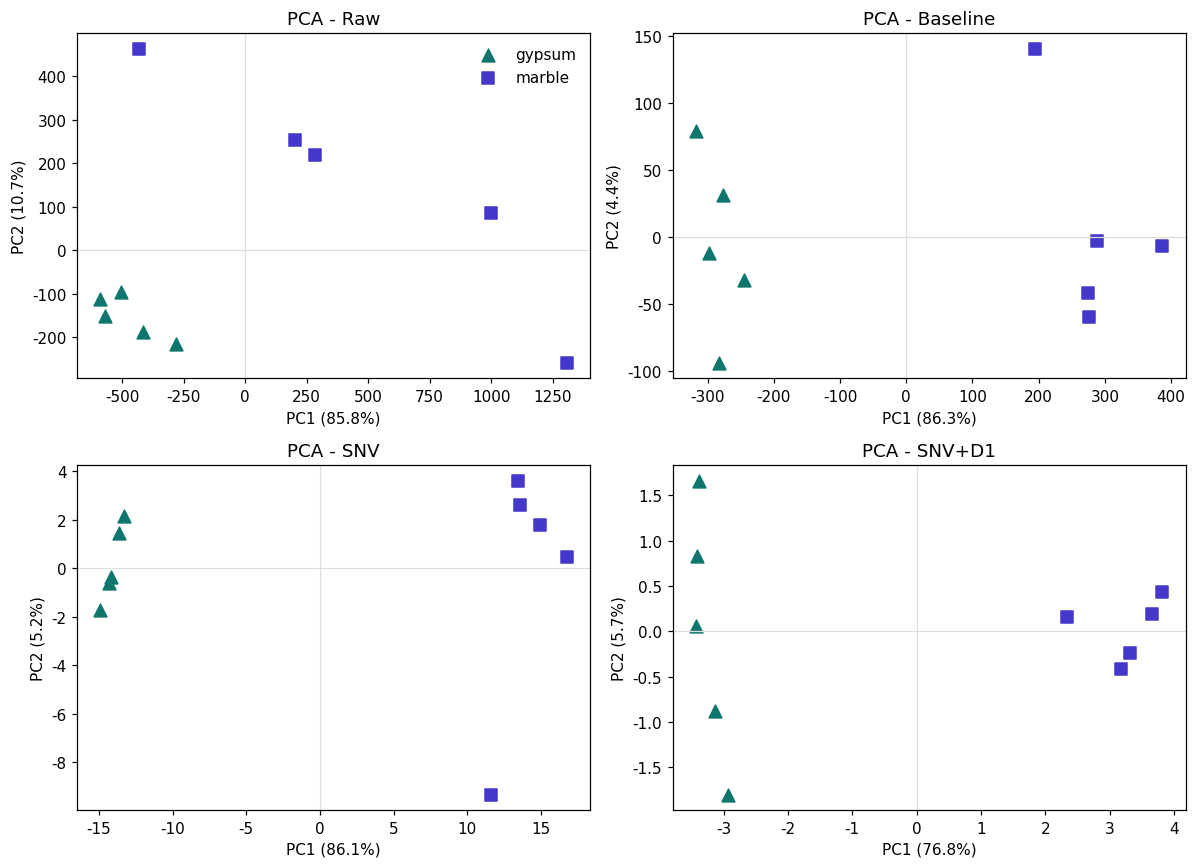

In [11]:
fig, ax = plt.subplots(2, 2, figsize=(11, 8))
for axi, (nm, M) in zip(ax.ravel(), SETS.items()):
    s, _, v = pca(M)
    for c in COL:
        m = lab == c
        axi.scatter(s[m, 0], s[m, 1], c=COL[c], marker=MRK[c], s=70, label=c)
    axi.axhline(0, color="#ddd", lw=.8); axi.axvline(0, color="#ddd", lw=.8)
    axi.set(xlabel=f"PC1 ({v[0]:.1f}%)", ylabel=f"PC2 ({v[1]:.1f}%)", title=f"PCA - {nm}")
ax[0, 0].legend(frameon=False)
fig.tight_layout()

### 4-1 Loading plots: translating a PC back into chemistry

A score plot tells you **who resembles whom**; a loading plot tells you **which peak is
responsible**. Reporting the first without the second is the most common shortcut in this field.

Ten largest |PC1 loadings|:
     1086.0   +0.2274   -> calcite side
     1083.5   +0.2135   -> calcite side
     1088.5   +0.2123   -> calcite side
      419.2   -0.2115   -> gypsum side
      283.5   +0.2072   -> calcite side
      286.4   +0.2051   -> calcite side
      422.1   -0.2006   -> gypsum side
      416.4   -0.1999   -> gypsum side
      280.6   +0.1926   -> calcite side
      289.4   +0.1861   -> calcite side


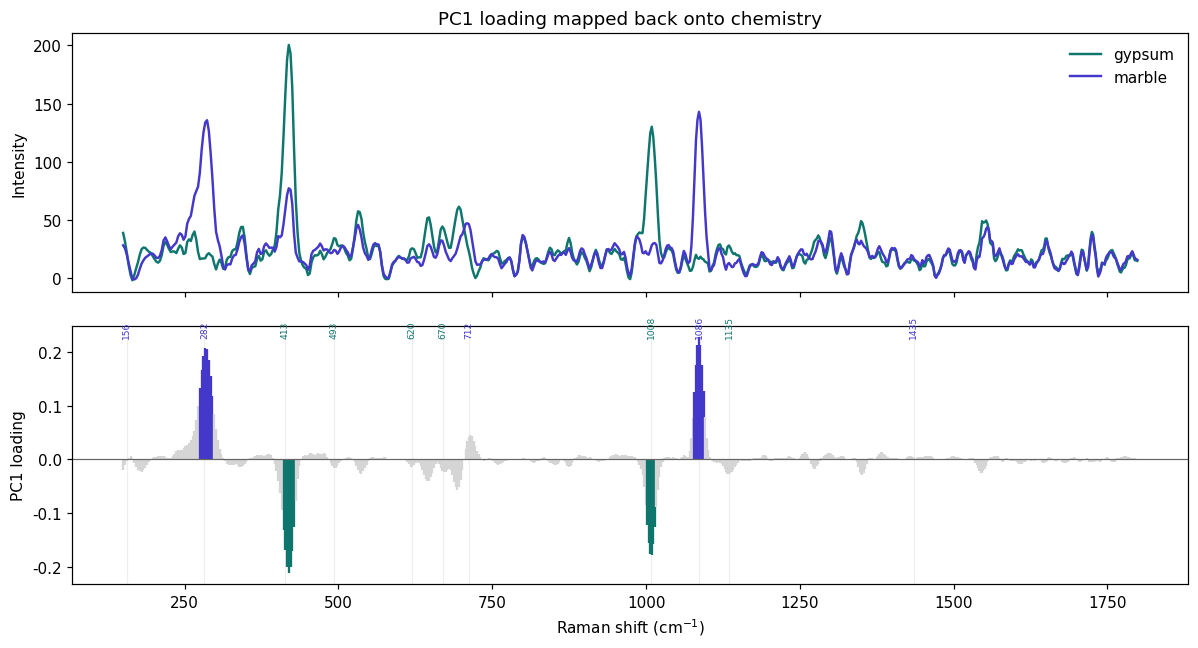

In [12]:
BANDS = {156:"cal", 282:"cal", 413:"gyp", 493:"gyp", 620:"gyp", 670:"gyp",
         712:"cal", 1008:"gyp", 1086:"cal", 1135:"gyp", 1435:"cal"}
GM = {c: Xbl[lab == c].mean(axis=0) for c in COL}

fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for c in COL: ax[0].plot(wn, GM[c], color=COL[c], lw=1.6, label=c)
ax[0].legend(frameon=False); ax[0].set_ylabel("Intensity")
ax[0].set_title("PC1 loading mapped back onto chemistry")
L = load[0]
ax[1].vlines(wn, 0, L, color=np.where(np.abs(L) > .10,
             np.where(L > 0, COL["marble"], COL["gypsum"]), "#d5d5d5"))
ax[1].axhline(0, color="#666", lw=.8)
for b, who in BANDS.items():
    ax[1].axvline(b, color="#eee", lw=.8, zorder=0)
    ax[1].text(b, ax[1].get_ylim()[1]*.92, str(b), rotation=90, fontsize=6,
               ha="center", color=COL["gypsum"] if who == "gyp" else COL["marble"])
ax[1].set(xlabel=XLAB, ylabel="PC1 loading")
fig.tight_layout()

top = np.argsort(-np.abs(L))[:10]
print("Ten largest |PC1 loadings|:")
for i in top:
    print(f"   {wn[i]:8.1f}   {L[i]:+.4f}   -> {'calcite side' if L[i] > 0 else 'gypsum side'}")

## 5. PLS-DA — supervised

PLS is a regression method at heart. To classify, encode the classes as a 0/1 **dummy
matrix Y**, regress it on X with PLS2, and predict by taking the largest output column.

The `plsda_fit` below is **the same implementation as `orangespectra/core.py` in the
`orange-spectra` package** (NIPALS PLS2, mean-centred, not scaled). It is reproduced here so
the notebook runs without the add-on installed; section 8 imports the real one for comparison.

In [13]:
_EPS = 1e-12

def plsda_fit(X, labels, n_components=2):
    X = np.asarray(X, float); labels = [str(v) for v in labels]
    classes = sorted(set(labels)); n, p = X.shape
    A = int(max(1, min(n_components, n - 1, p)))
    Y = np.zeros((n, len(classes)))
    for i, l in enumerate(labels): Y[i, classes.index(l)] = 1.0

    x_mean, y_mean = X.mean(axis=0), Y.mean(axis=0)
    Xc, Yc = X - x_mean, Y - y_mean
    T = np.zeros((n, A)); W = np.zeros((p, A))
    P = np.zeros((p, A)); Q = np.zeros((len(classes), A))
    Xa, Ya = Xc.copy(), Yc.copy()
    for a in range(A):                                   # NIPALS
        u = Ya[:, int(np.argmax(Ya.var(axis=0)))]
        for _ in range(500):
            w = Xa.T @ u; w /= (np.linalg.norm(w) or 1.0)
            t = Xa @ w
            q = Ya.T @ t / max(t @ t, _EPS)
            u_new = Ya @ q / max(q @ q, _EPS)
            if np.linalg.norm(u_new - u) <= 1e-10 * max(np.linalg.norm(u), 1.0):
                u = u_new; break
            u = u_new
        t  = Xa @ w
        pa = Xa.T @ t / max(t @ t, _EPS)
        q  = Ya.T @ t / max(t @ t, _EPS)
        Xa = Xa - np.outer(t, pa); Ya = Ya - np.outer(t, q)   # deflation
        T[:, a], W[:, a], P[:, a], Q[:, a] = t, w, pa, q

    B = W @ np.linalg.solve(P.T @ W, Q.T)                # regression coefficients
    y_hat = Xc @ B + y_mean
    pred_idx = np.argmax(y_hat, axis=1)
    truth = np.array([classes.index(l) for l in labels])
    accuracy = float(np.mean(pred_idx == truth))

    # VIP_j = sqrt( p * sum_a( ssy_a * (w_ja/||w_a||)^2 ) / sum_a ssy_a )
    ssy = np.array([(T[:, a] @ T[:, a]) * (Q[:, a] @ Q[:, a]) for a in range(A)])
    wnorm2 = np.maximum((W**2).sum(axis=0), _EPS)
    vip = np.sqrt(p * ((W**2) / wnorm2 @ ssy) / max(ssy.sum(), _EPS))

    total = float((Xc**2).sum()) or 1.0
    xvar = np.array([(np.outer(T[:, a], P[:, a])**2).sum() / total for a in range(A)])
    return dict(classes=classes, n_components=A, scores=T, loadings=P, weights=W,
                y_loadings=Q, vip=vip, coef=B, x_mean=x_mean, y_mean=y_mean,
                y_hat=y_hat, predicted=[classes[i] for i in pred_idx],
                accuracy=accuracy, explained_x_variance=xvar)

training accuracy : 1.0
explained X variance per component (%) : [86.3   3.98]


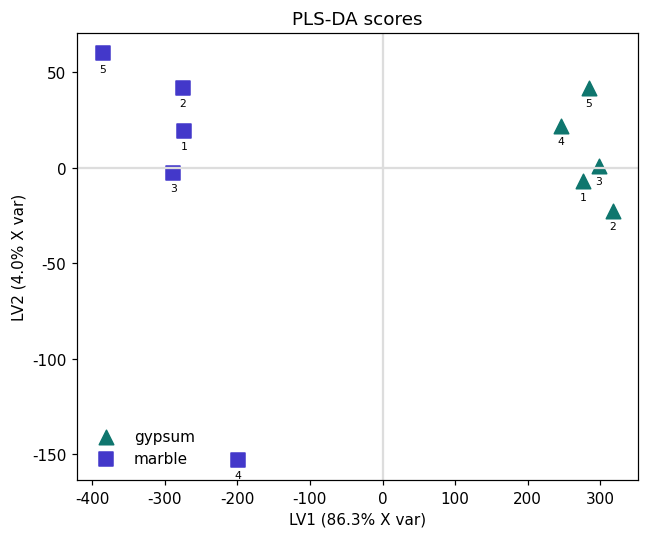

In [14]:
res = plsda_fit(Xbl, lab, n_components=2)
print("training accuracy :", res["accuracy"])
print("explained X variance per component (%) :", np.round(100 * res["explained_x_variance"], 2))

T, xv = res["scores"], res["explained_x_variance"]
fig, axi = plt.subplots(figsize=(6, 5))
for c in COL:
    m = lab == c
    axi.scatter(T[m, 0], T[m, 1], c=COL[c], marker=MRK[c], s=90, label=c)
for i, s in enumerate(ids): axi.annotate(s[-1], (T[i, 0], T[i, 1]), fontsize=7,
                                         xytext=(0, -12), textcoords="offset points", ha="center")
axi.axhline(0, color="#ddd"); axi.axvline(0, color="#ddd")
axi.set(xlabel=f"LV1 ({xv[0]:.1%} X var)", ylabel=f"LV2 ({xv[1]:.1%} X var)",
        title="PLS-DA scores")
axi.legend(frameon=False); fig.tight_layout()

## 6. VIP — which wavenumbers the model is using

VIP > 1 is the conventional threshold, because the mean of the squared VIP scores is exactly
1, so "greater than 1" means "above average contribution".

In [15]:
V = res["vip"]
order = np.argsort(-V)[:15]
print(f"wavenumbers with VIP > 1: {(V > 1).sum()} / {len(V)}\n")
print(" rank   cm-1      VIP    assignment")
ASSIGN = {1086:"calcite CO3 v1  * real", 1083:"calcite CO3 v1 shoulder", 1088:"calcite CO3 v1 shoulder",
          419:"INSTRUMENT ARTEFACT", 422:"INSTRUMENT ARTEFACT", 416:"artefact + gypsum v2 overlap",
          413:"gypsum SO4 v2", 424:"INSTRUMENT ARTEFACT", 427:"INSTRUMENT ARTEFACT",
          283:"calcite lattice *", 286:"calcite lattice *", 280:"calcite lattice *",
          289:"calcite lattice *", 292:"calcite lattice", 277:"calcite lattice",
          1009:"gypsum SO4 v1  * real", 1006:"gypsum SO4 v1 *", 1004:"gypsum SO4 v1 shoulder",
          1011:"gypsum SO4 v1 shoulder", 1081:"calcite CO3 v1 shoulder", 1090:"calcite CO3 v1 shoulder"}
for r_, i in enumerate(order, 1):
    print(f" {r_:>3d}  {wn[i]:8.1f}  {V[i]:6.3f}   {ASSIGN.get(int(wn[i]), '')}")

wavenumbers with VIP > 1: 55 / 664

 rank   cm-1      VIP    assignment
   1    1086.0   5.718   calcite CO3 v1  * real
   2     419.2   5.574   INSTRUMENT ARTEFACT
   3    1083.5   5.373   calcite CO3 v1 shoulder
   4    1088.5   5.338   calcite CO3 v1 shoulder
   5     422.1   5.310   INSTRUMENT ARTEFACT
   6     283.5   5.249   calcite lattice *
   7     416.4   5.244   artefact + gypsum v2 overlap
   8     286.4   5.200   calcite lattice *
   9     280.6   4.880   calcite lattice *
  10     289.4   4.720   calcite lattice *
  11    1009.3   4.581   gypsum SO4 v1  * real
  12    1006.8   4.530   gypsum SO4 v1 *
  13     424.9   4.528   INSTRUMENT ARTEFACT
  14    1081.1   4.445   calcite CO3 v1 shoulder
  15     413.5   4.414   gypsum SO4 v2


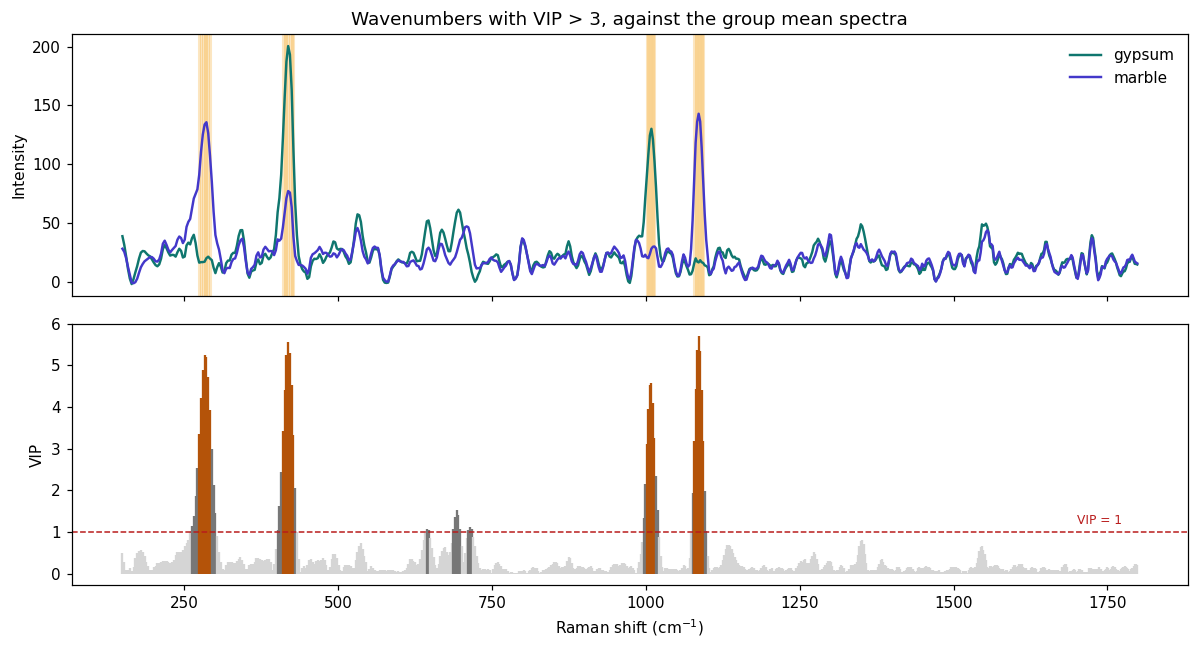

In [16]:
fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for c in COL: ax[0].plot(wn, GM[c], color=COL[c], lw=1.6, label=c)
for w_ in wn[V > 3]: ax[0].axvline(w_, color="#F59E0B", alpha=.25, lw=2, zorder=0)
ax[0].legend(frameon=False); ax[0].set_ylabel("Intensity")
ax[0].set_title("Wavenumbers with VIP > 3, against the group mean spectra")
ax[1].vlines(wn, 0, V, color=np.where(V > 3, "#B45309", np.where(V > 1, "#777", "#d5d5d5")))
ax[1].axhline(1, color="#B91C1C", ls="--", lw=1)
ax[1].text(1700, 1.2, "VIP = 1", color="#B91C1C", fontsize=8)
ax[1].set(xlabel=XLAB, ylabel="VIP")
fig.tight_layout()

**Ranks 2, 5 and 7 — 419 / 422 / 416 — are the instrument artefact.**

The model is placing substantial weight on a signal that does not come from the sample. That
is not the algorithm's fault: VIP only reports that the model used a variable, never whether
it means anything. Deciding that is your job — and it is only possible because you did the
band assignment in section 3 *before* fitting anything.

In [17]:
# The two PLS loadings — compare these with Orange's Loadings output
for a in range(2):
    L_ = res["loadings"][:, a]; o = np.argsort(-np.abs(L_))[:6]
    print(f"p{a+1}: " + "  ".join(f"{wn[i]:.1f}({L_[i]:+.3f})" for i in o))

p1: 1086.0(-0.227)  1083.5(-0.213)  1088.5(-0.212)  419.2(+0.212)  283.5(-0.207)  286.4(-0.205)
p2: 422.1(+0.249)  419.2(+0.248)  424.9(+0.225)  416.4(+0.219)  1086.0(+0.206)  1083.5(+0.199)


Look at **p2**: its four largest entries all fall in the 419 artefact band. The second latent
variable is essentially an *instrument artefact component*. It carries only 3.98% of the X
variance and — as the next section shows — is not needed for classification at all. But set
Components = 2 (the usual default) and it is there, skewing the whole VIP ranking.

A useful rule follows: if the largest loadings of a component are **clustered in one narrow
band** whose chemical assignment you cannot state, assume it is instrumental until you can
prove otherwise. A genuine chemical component spreads its loadings over several bands of the
same mineral — as p1 does, across 1086, 1083, 1088, 283 and 286.

## 7. Validation: can 100% accuracy be believed?

### 7-1 Leave-one-out cross-validation
With n = 10, leave-one-out is the only sensible choice. **The model must be rebuilt on every
fold** — feeding the held-out sample to an already-fitted model proves nothing.

In [18]:
def predict(fit, x):
    yh = (x - fit["x_mean"]) @ fit["coef"] + fit["y_mean"]
    return fit["classes"][int(np.argmax(yh))]

def loocv(M, labels, A=2):
    labels = np.asarray(labels); ok = 0
    for i in range(len(labels)):
        m = np.ones(len(labels), bool); m[i] = False
        ok += predict(plsda_fit(M[m], labels[m].tolist(), A), M[i]) == labels[i]
    return ok / len(labels)

for nm, M in SETS.items():
    print(f"  {nm:<9s}", "  ".join(f"{a}LV={loocv(M, lab, a):.3f}" for a in (1, 2, 3, 4)))

  Raw       1LV=0.900  2LV=1.000  3LV=1.000  4LV=1.000
  Baseline  1LV=1.000  2LV=1.000  3LV=1.000  4LV=1.000
  SNV       1LV=1.000  2LV=1.000  3LV=1.000  4LV=1.000
  SNV+D1    1LV=1.000  2LV=1.000  3LV=1.000  4LV=1.000


### 7-2 Exact permutation test

The sample is small enough that random permutation is wasteful — five versus five allows only
**C(10,5) = 252** label assignments. Enumerate all of them and the p-value is exact rather
than an estimate.

observed = 1.000   mean under shuffled labels = 0.426   max = 1.000
p = 2/252 = 0.0079


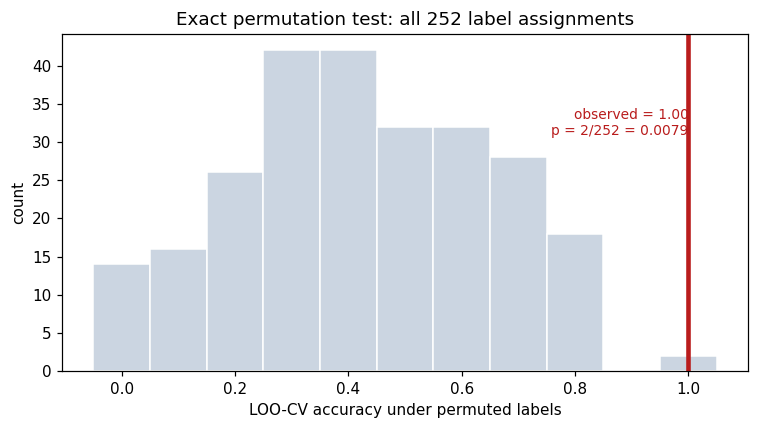

In [19]:
from itertools import combinations
cls = sorted(set(lab))
accs = np.array([loocv(Xbl, [cls[0] if i in idx else cls[1] for i in range(10)], 2)
                 for idx in combinations(range(10), 5)])
obs = loocv(Xbl, lab, 2)
p = (accs >= obs).sum() / len(accs)
print(f"observed = {obs:.3f}   mean under shuffled labels = {accs.mean():.3f}   max = {accs.max():.3f}")
print(f"p = {(accs >= obs).sum()}/{len(accs)} = {p:.4f}")

fig, axi = plt.subplots(figsize=(7, 4))
axi.hist(accs, bins=np.arange(-.05, 1.15, .1), color="#CBD5E1", edgecolor="white")
axi.axvline(obs, color="#B91C1C", lw=3)
axi.set(xlabel="LOO-CV accuracy under permuted labels", ylabel="count",
        title=f"Exact permutation test: all {len(accs)} label assignments")
axi.annotate(f"observed = {obs:.2f}\np = {(accs>=obs).sum()}/{len(accs)} = {p:.4f}",
             (obs, axi.get_ylim()[1]*.7), ha="right", color="#B91C1C", fontsize=9)
fig.tight_layout()

**Only two assignments reach 100%** — the true labelling, and the one with both labels
swapped (the model simply learns the reversed mapping and scores identically).

So **p = 2/252 = 0.0079 is the floor for a five-versus-five design**. However perfect your
signal, you cannot go lower. That is something to know while designing the experiment, not
after analysing it: for p < 0.001 you need at least six spectra per group
(C(12,6) = 924, so 2/924 = 0.0022).

## 8. Three tools, one set of numbers

Now compare the Python results against R's output, and against the real `plsda_fit` inside
the `orange-spectra` package.

In [20]:
R = pd.read_csv("../data/loadings_vip_R.csv")     # produced by the R script
print("=== hand-written Python vs R (pls::oscorespls) ===")
print(f"  VIP        max |diff| = {np.abs(V - R['VIP'].to_numpy()).max():.3e}")
for a, c in [(0, "PLS_p1"), (1, "PLS_p2")]:
    lp, lr = res["loadings"][:, a], R[c].to_numpy()
    s = np.sign(lp @ lr)                          # loading signs may flip as a whole
    print(f"  {c:<10s} max |diff| = {np.abs(lp*s - lr).max():.3e}   r = {np.corrcoef(lp, lr)[0,1]:+.10f}")
for a, c in [(0, "PC1"), (1, "PC2")]:
    lp, lr = load[a], R[c].to_numpy(); s = np.sign(lp @ lr)
    print(f"  {c:<10s} max |diff| = {np.abs(lp*s - lr).max():.3e}")

=== hand-written Python vs R (pls::oscorespls) ===
  VIP        max |diff| = 5.000e-07
  PLS_p1     max |diff| = 4.995e-07   r = +1.0000000000
  PLS_p2     max |diff| = 4.999e-07   r = +1.0000000000
  PC1        max |diff| = 4.987e-07
  PC2        max |diff| = 4.980e-07


In [21]:
# The real package function - this is what the Orange PLS-DA widget calls internally
try:
    from orangespectra.core import plsda_fit as pkg_plsda_fit
    r2 = pkg_plsda_fit(Xbl, list(lab), 2)
    print("=== hand-written vs the orange-spectra package ===")
    print(f"  VIP      max |diff| = {np.abs(V - r2['vip']).max():.3e}")
    print(f"  scores   max |diff| = {np.abs(res['scores'] - r2['scores']).max():.3e}")
    print(f"  accuracy  {res['accuracy']}  vs  {r2['accuracy']}")
except ImportError:
    print("orange-spectra not installed, skipping.")
    print("To compare the algorithm without installing all of Orange:")
    print("    pip install orange-spectra --no-deps")

=== hand-written vs the orange-spectra package ===
  VIP      max |diff| = 0.000e+00
  scores   max |diff| = 0.000e+00
  accuracy  1.0  vs  1.0


All three agree to better than 10⁻⁶, and the residual comes only from rounding on CSV export.

That means the **VIP table you see when you click in the Orange widget**, the VIP array in
this notebook, and the VIP vector from the R script are the *same numbers* — not merely
similar. Tools differ in interface, not in results.

## 9. Next

- **Orange**: see the `orange/` folder. Load `data/rock_preprocessed.tab` into a File widget,
  connect it to **PLS-DA**, set Components to 2, and you get the same score plot and the same
  VIP table. Insert a **Transpose** between Loadings and the **Spectra** widget to see the
  loadings as curves.
- **R**: `r/rock_raman_tutorial.R` (Chinese comments) or `r/rock_raman_tutorial_en.R` (English).
- The full tutorial, including the chemistry and every pitfall: `index_en.html`.